## Generative Adversarial Network (GAN)

**Nama:** Neilson Christopher
**NIM:** 2802461965
**Kelas dataset:** Stadium & Oil Gas Field

Link Video: https://drive.google.com/drive/folders/1Z_Wg2k70WxFug2BxPFwJsSRnaXBk6YZD?usp=sharing


## Membangun Arsitektur GAN untuk Image Generation
**[LO 3, LO 4, 10 poin]**

Kita akan membangun **Conditional GAN (CGAN)** sesuai dengan gambar arsitektur pada soal, yang terdiri dari:

**Generator:**
`Noise Input + Labels` → `Embedding(labels)` → `Dense(noise+n_labels, 128)` → `Dense(128,256)` → `Dense(256,512)` → `Dense(512,1024)` → `Dense(1024, img_size**2)`

**Discriminator:**
`Images + Labels` → `Embedding(labels)` → `Dense(n_labels+img_size**2, 512)` → `Dense(512,1024)` → `Dense(1024,1024)` → `Dense(1024,512)` → `Dense(512,1)` → `Real/Fake`


In [2]:
# 1. Import library
import os
import matplotlib.pyplot as plt
from PIL import Image
from scipy import linalg
import json
import random
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Mematikan optimizer 'remapping' grappler TF untuk menghindari warning internal
# yang kadang muncul pada model dengan banyak skip-connection kecil (tidak memengaruhi hasil)
tf.config.optimizer.set_experimental_options({"remapping": False})

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU tersedia: True


In [3]:
zip_path = "/content/archive (1).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Ekstraksi selesai")

Ekstraksi selesai


In [21]:
BASE_DIR = "/content/dataset/archive (1)/version2"
CLASSES = {"stadium": 0, "oil_gas_field": 1}
IMG_SIZE = 28
N_LABELS = len(CLASSES)

def load_split(split):
    folder = "train" if split == "train" else "test"
    imgs, labels = [], []
    for cls_name, cls_idx in CLASSES.items():
        cls_dir = os.path.join(BASE_DIR, folder, cls_name)
        for fname in sorted(os.listdir(cls_dir)):
            img = Image.open(os.path.join(cls_dir, fname)).convert("L")  # grayscale
            arr = np.array(img, dtype=np.float32)
            imgs.append(arr)
            labels.append(cls_idx)
    return np.stack(imgs), np.array(labels)

X_train_full, y_train_full = load_split("train")
X_test, y_test = load_split("test")

print("Train+Val (sebelum split):", X_train_full.shape, y_train_full.shape)
print("Test:", X_test.shape, y_test.shape)
print("Distribusi kelas train:", np.unique(y_train_full, return_counts=True))
print("Distribusi kelas test:", np.unique(y_test, return_counts=True))

Train+Val (sebelum split): (13869, 28, 28) (13869,)
Test: (1720, 28, 28) (1720,)
Distribusi kelas train: (array([0, 1]), array([6756, 7113]))
Distribusi kelas test: (array([0, 1]), array([840, 880]))


In [22]:
# Split menjadi train (80%) dan validation (10%) dari data training awal,
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1111,  # 0.1111 dari 90% sisa data train+val ~= 10% dari total
    stratify=y_train_full,
    random_state=42
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"Proporsi -> train: {X_train.shape[0]/total:.1%}, val: {X_val.shape[0]/total:.1%}, test: {X_test.shape[0]/total:.1%}")

Train: (12328, 28, 28)  Val: (1541, 28, 28)  Test: (1720, 28, 28)
Proporsi -> train: 79.1%, val: 9.9%, test: 11.0%


Range pixel setelah scaling: -1.0 sampai 1.0


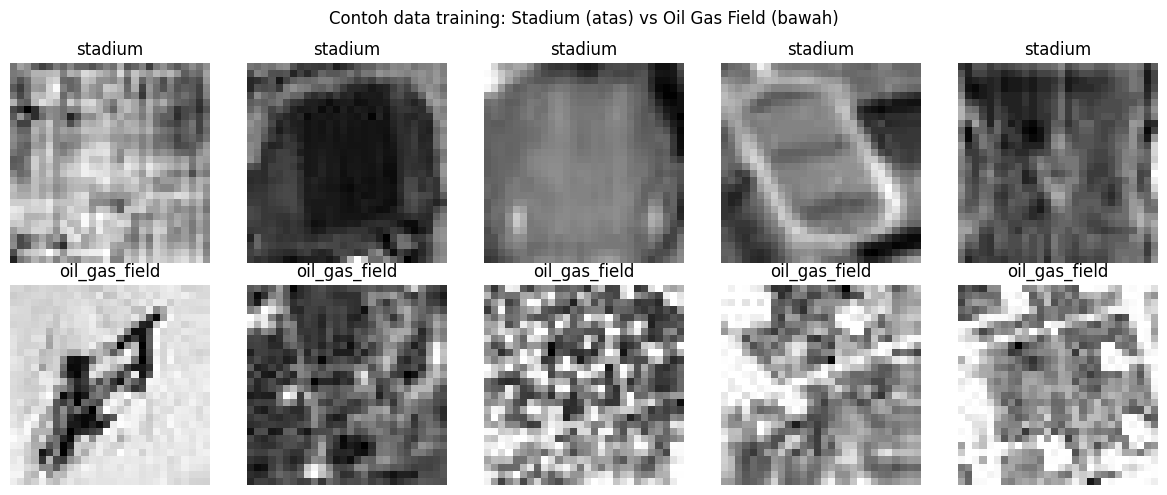

In [23]:
def scale_to_tanh_range(X):
    return (X.astype(np.float32) / 127.5) - 1.0

X_train_scaled = scale_to_tanh_range(X_train)
X_val_scaled   = scale_to_tanh_range(X_val)
X_test_scaled  = scale_to_tanh_range(X_test)

print("Range pixel setelah scaling:", X_train_scaled.min(), "sampai", X_train_scaled.max())

# Tampilkan contoh data dari masing-masing kelas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls_name, cls_idx in CLASSES.items():
    idxs = np.where(y_train == cls_idx)[0][:5]
    row = cls_idx
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(X_train[idx], cmap="gray")
        axes[row, col].set_title(cls_name)
        axes[row, col].axis("off")
plt.suptitle("Contoh data training: Stadium (atas) vs Oil Gas Field (bawah)")
plt.tight_layout()
plt.show()

Dataset memuat 15.589 citra grayscale berukuran 28×28 piksel, yang dibagi menjadi 12.328 data training (79,1%), 1.541 data validasi (9,9%), dan 1.720 data test (11,0%). Distribusi kelas relatif seimbang: pada data train+validation terdapat 6.756 citra stadium dan 7.113 citra oil gas field, sedangkan data test terdiri dari 840 dan 880 citra. Keseimbangan ini mengurangi risiko model lebih sering menghasilkan satu kelas hanya karena kelas tersebut lebih dominan.
Nilai piksel berhasil dinormalisasi ke rentang [-1, 1], sesuai dengan aktivasi tanh pada keluaran Generator. Contoh citra menunjukkan variasi bentuk dan tekstur yang cukup tinggi di dalam setiap kelas. Pada resolusi rendah, ciri objek menjadi kurang tegas; karena itu model perlu mempelajari pola global sekaligus tekstur lokal untuk membedakan karakteristik stadium dan oil gas field.

In [24]:
# Siapkan data dalam format (N, H, W, C) untuk Keras, dan buat tf.data.Dataset
NOISE_DIM = 100
BATCH_SIZE = 64

X_train_arr = X_train_scaled[..., np.newaxis].astype(np.float32)  # (N, 28, 28, 1)
y_train_arr = y_train.astype(np.int32)

X_test_arr = X_test_scaled[..., np.newaxis].astype(np.float32)
y_test_arr = y_test.astype(np.int32)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_arr, y_train_arr))
train_dataset = train_dataset.shuffle(1024, seed=42).batch(BATCH_SIZE, drop_remainder=True)

print("Jumlah batch per epoch:", len(list(train_dataset.as_numpy_iterator())))

Jumlah batch per epoch: 192


### Arsitektur Baseline CGAN

Mengikuti gambar arsitektur pada soal secara presisi: Generator dan Discriminator berbasis **fully-connected (Dense) layers**, dengan informasi kelas disuntikkan melalui layer `Embedding`. Dibangun dengan **Keras Functional API** karena model membutuhkan dua input (noise/gambar dan label).


In [25]:
def build_generator(noise_dim=NOISE_DIM, n_labels=N_LABELS, img_size=IMG_SIZE):
    noise_input = layers.Input(shape=(noise_dim,), name="noise_input")
    label_input = layers.Input(shape=(1,), dtype="int32", name="label_input")

    label_embed = layers.Embedding(n_labels, n_labels)(label_input)
    label_embed = layers.Flatten()(label_embed)

    x = layers.Concatenate()([noise_input, label_embed])
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dense(img_size * img_size, activation="tanh")(x)
    output = layers.Reshape((img_size, img_size, 1))(x)

    return keras.Model([noise_input, label_input], output, name="Generator")


def build_discriminator(n_labels=N_LABELS, img_size=IMG_SIZE):
    img_input = layers.Input(shape=(img_size, img_size, 1), name="img_input")
    label_input = layers.Input(shape=(1,), dtype="int32", name="label_input")

    img_flat = layers.Flatten()(img_input)
    label_embed = layers.Embedding(n_labels, n_labels)(label_input)
    label_embed = layers.Flatten()(label_embed)

    x = layers.Concatenate()([img_flat, label_embed])
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dense(1024)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dense(1024)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model([img_input, label_input], output, name="Discriminator")


G = build_generator()
D = build_discriminator()
G.summary()
D.summary()
print("Total parameter Generator:", G.count_params())
print("Total parameter Discriminator:", D.count_params())

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 2)      │          4 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 2)         │          0 │ embedding_10[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 102)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │     13,184 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_28      │ (None, 128)       │          0 │ dense_18[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │     33,024 │ leaky_re_lu_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_19[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_29      │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 512)       │    131,584 │ leaky_re_lu_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_30      │ (None, 512)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1024)      │    525,312 │ leaky_re_lu_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_21[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_31      │ (None, 1024)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 784)       │    803,600 │ leaky_re_lu_31[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_22[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,513,876 (5.77 MB)

 Trainable params: 1,510,292 (5.76 MB)

 Non-trainable params: 3,584 (14.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 1, 2)      │          4 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 784)       │          0 │ img_input[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 2)         │          0 │ embedding_11[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 786)       │          0 │ flatten_12[0][0], │
│ (Concatenate)       │                   │            │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 512)       │    402,944 │ concatenate_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_32      │ (None, 512)       │          0 │ dense_23[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1024)      │    525,312 │ leaky_re_lu_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 1024)      │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_33      │ (None, 1024)      │          0 │ dropout_14[0][0]  │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 1024)      │  1,049,600 │ leaky_re_lu_33[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 1024)      │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_34      │ (None, 1024)      │          0 │ dropout_15[0][0]  │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 512)       │    524,800 │ leaky_re_lu_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_35      │ (None, 512)       │          0 │ dense_26[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │        513 │ leaky_re_lu_35[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,503,173 (9.55 MB)

 Trainable params: 2,503,173 (9.55 MB)

 Non-trainable params: 0 (0.00 B)

Total parameter Generator: 1513876
Total parameter Discriminator: 2503173


In [26]:
# 4. Training loop CGAN baseline (custom training step dengan tf.GradientTape)

bce = keras.losses.BinaryCrossentropy()
opt_G = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
opt_D = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

LABEL_SMOOTH_REAL = 0.9  # label smoothing ringan agar Discriminator tidak terlalu percaya diri

@tf.function
def train_step(real_imgs, real_labels):
    bs = tf.shape(real_imgs)[0]
    real_labels_col = tf.reshape(real_labels, (-1, 1))

    noise = tf.random.normal((bs, NOISE_DIM))
    gen_labels = tf.random.uniform((bs, 1), 0, N_LABELS, dtype=tf.int32)

    valid = tf.ones((bs, 1)) * LABEL_SMOOTH_REAL
    fake = tf.zeros((bs, 1))

    # ---- Train Discriminator ----
    with tf.GradientTape() as tape_d:
        fake_imgs = G([noise, gen_labels], training=True)
        real_pred = D([real_imgs, real_labels_col], training=True)
        fake_pred = D([fake_imgs, gen_labels], training=True)
        d_loss_real = bce(valid, real_pred)
        d_loss_fake = bce(fake, fake_pred)
        d_loss = (d_loss_real + d_loss_fake) / 2
    grads_d = tape_d.gradient(d_loss, D.trainable_variables)
    opt_D.apply_gradients(zip(grads_d, D.trainable_variables))

    # ---- Train Generator ----
    with tf.GradientTape() as tape_g:
        fake_imgs = G([noise, gen_labels], training=True)
        fake_pred = D([fake_imgs, gen_labels], training=True)
        g_loss = bce(tf.ones((bs, 1)), fake_pred)
    grads_g = tape_g.gradient(g_loss, G.trainable_variables)
    opt_G.apply_gradients(zip(grads_g, G.trainable_variables))

    return d_loss, g_loss


EPOCHS = 100
g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    epoch_g_loss, epoch_d_loss, n_batches = 0.0, 0.0, 0
    for real_imgs, real_labels in train_dataset:
        d_loss, g_loss = train_step(real_imgs, real_labels)
        epoch_g_loss += float(g_loss)
        epoch_d_loss += float(d_loss)
        n_batches += 1

    g_losses.append(epoch_g_loss / n_batches)
    d_losses.append(epoch_d_loss / n_batches)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  D_loss: {d_losses[-1]:.4f}  G_loss: {g_losses[-1]:.4f}")

print("Training baseline CGAN selesai.")

Epoch [1/100]  D_loss: 0.5676  G_loss: 2.0394
Epoch [10/100]  D_loss: 0.6173  G_loss: 1.2106
Epoch [20/100]  D_loss: 0.6401  G_loss: 1.1018
Epoch [30/100]  D_loss: 0.6366  G_loss: 1.0935
Epoch [40/100]  D_loss: 0.6347  G_loss: 1.0942
Epoch [50/100]  D_loss: 0.6407  G_loss: 1.0774
Epoch [60/100]  D_loss: 0.6276  G_loss: 1.1280
Epoch [70/100]  D_loss: 0.6360  G_loss: 1.0919
Epoch [80/100]  D_loss: 0.6282  G_loss: 1.1192
Epoch [90/100]  D_loss: 0.6153  G_loss: 1.1640
Epoch [100/100]  D_loss: 0.6152  G_loss: 1.1921
Training baseline CGAN selesai.


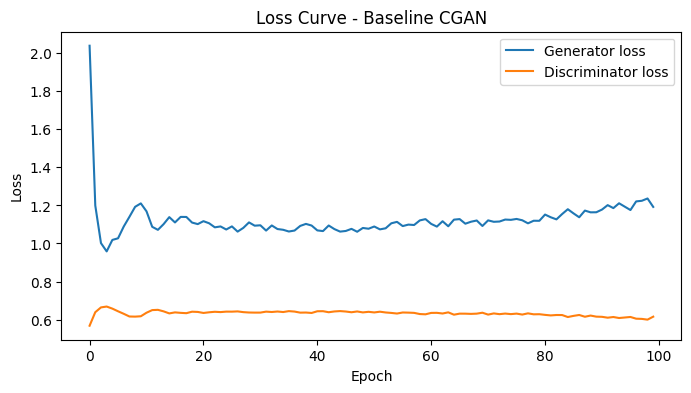

In [27]:
# Visualisasi loss curve
plt.figure(figsize=(8,4))
plt.plot(g_losses, label="Generator loss")
plt.plot(d_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve - Baseline CGAN")
plt.legend()
plt.show()

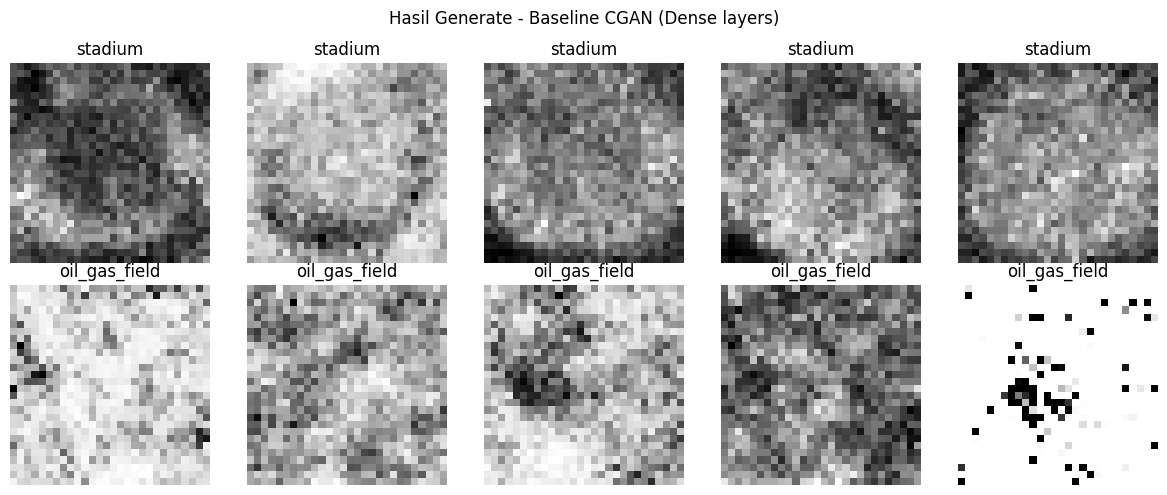

In [28]:
# Visualisasi hasil generate gambar (baseline) per kelas
n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(12, 5))
for cls_name, cls_idx in CLASSES.items():
    noise = tf.random.normal((n_show, NOISE_DIM))
    labels_in = tf.fill((n_show, 1), cls_idx)
    gen_imgs = G([noise, labels_in], training=False).numpy()
    gen_imgs = (gen_imgs + 1) / 2.0  # un-normalize dari [-1,1] ke [0,1]
    for col in range(n_show):
        axes[cls_idx, col].imshow(gen_imgs[col, :, :, 0], cmap="gray")
        axes[cls_idx, col].set_title(cls_name)
        axes[cls_idx, col].axis("off")
plt.suptitle("Hasil Generate - Baseline CGAN (Dense layers)")
plt.tight_layout()
plt.show()

Pada 100 epoch, loss Discriminator bergerak dari 0,5676 menjadi 0,6152, sedangkan loss Generator turun tajam pada fase awal lalu berada di sekitar 1,1 dan berakhir pada 1,1921. Kurva tidak mengalami ledakan loss, sehingga training dapat dikatakan cukup stabil. Loss Generator yang tetap lebih tinggi menunjukkan bahwa Discriminator masih relatif lebih kuat dalam mengenali citra hasil generasi.
Loss pada GAN tidak harus terus menurun seperti pada model klasifikasi; yang lebih penting adalah adanya keseimbangan permainan antara Generator dan Discriminator. Secara visual, baseline sudah menghasilkan perbedaan tekstur antarkelas, tetapi beberapa sampel masih tampak kasar, berisik, atau memiliki pola piksel ekstrem. Ini menunjukkan bahwa Dense layer telah menangkap karakter umum kelas, tetapi belum cukup baik dalam membentuk struktur spasial citra yang realistis.

### Evaluasi dengan Fréchet Inception Distance (FID)

FID mengukur seberapa dekat distribusi statistik (mean & covariance) dari fitur gambar hasil generate dibandingkan dengan fitur gambar asli (data test), dengan fitur diekstrak menggunakan jaringan **InceptionV3** pretrained pada ImageNet.

Rumus FID:

$$FID = \|\mu_r - \mu_f\|^2 + Tr(\Sigma_r + \Sigma_f - 2(\Sigma_r \Sigma_f)^{1/2})$$

di mana $\mu_r, \Sigma_r$ adalah mean dan covariance fitur dari gambar real (test set), dan $\mu_f, \Sigma_f$ adalah mean dan covariance fitur dari gambar fake (hasil generate). FID semakin **kecil** semakin baik (distribusi fake mendekati distribusi real).

Karena InceptionV3 didesain untuk input RGB 299x299, kita perlu:
1. Resize gambar 28x28 grayscale menjadi 299x299
2. Duplikasi channel grayscale menjadi 3 channel (RGB)
3. Ekstrak fitur dari layer pooling akhir (`pooling="avg"`, dimensi 2048), menggunakan `include_top=False`

**Catatan teknis:** ekstraksi fitur dilakukan per-batch kecil (bukan sekaligus semua data) untuk menjaga penggunaan memori tetap aman, terutama jika dijalankan di mesin dengan RAM terbatas.


In [29]:
# 5. Implementasi FID

from tensorflow.keras.applications import InceptionV3

def get_inception_feature_extractor():
    inception = InceptionV3(
        include_top=False,
        pooling="avg",          # global average pooling -> fitur dimensi 2048
        weights="imagenet",
        input_shape=(299, 299, 3)
    )
    return inception

inception_model = get_inception_feature_extractor()

def preprocess_for_inception(imgs_np):
    """imgs_np: numpy (B, 28, 28, 1) range [-1, 1] -> tensor (B, 299, 299, 3) range [-1, 1]"""
    imgs = tf.convert_to_tensor(imgs_np, dtype=tf.float32)
    imgs = (imgs + 1.0) / 2.0                              # ke [0, 1]
    imgs = tf.image.grayscale_to_rgb(imgs)                  # 1 channel -> 3 channel
    imgs = tf.image.resize(imgs, (299, 299), method="bilinear")
    imgs = imgs * 2.0 - 1.0                                  # preprocessing InceptionV3 (expects [-1,1])
    return imgs

def extract_inception_features(imgs_np, batch_size=16):
    feats = []
    n = imgs_np.shape[0]
    for i in range(0, n, batch_size):
        batch_np = imgs_np[i:i+batch_size]
        batch_tf = preprocess_for_inception(batch_np)
        feat = inception_model(batch_tf, training=False)
        feats.append(feat.numpy())
    return np.concatenate(feats, axis=0)

def calculate_fid(real_feats, fake_feats, eps=1e-6):
    mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2

    offset = np.eye(sigma1.shape[0]) * eps
    covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

print("Feature extractor (InceptionV3) siap digunakan.")

Feature extractor (InceptionV3) siap digunakan.


In [30]:
# Hitung FID untuk baseline CGAN menggunakan data TEST sebagai "real" images

def generate_fake_batch(generator, n_samples, class_idx=None, seed=None):
    if seed is not None:
        tf.random.set_seed(seed)
    noise = tf.random.normal((n_samples, NOISE_DIM))
    if class_idx is None:
        labels_in = tf.random.uniform((n_samples, 1), 0, N_LABELS, dtype=tf.int32)
    else:
        labels_in = tf.fill((n_samples, 1), class_idx)
    fake_imgs = generator([noise, labels_in], training=False)
    return fake_imgs.numpy()

n_test = X_test_arr.shape[0]
fake_imgs_baseline = generate_fake_batch(G, n_test, seed=123)  # generate sejumlah sama dengan test set

real_feats = extract_inception_features(X_test_arr)
fake_feats_baseline = extract_inception_features(fake_imgs_baseline)

fid_baseline = calculate_fid(real_feats, fake_feats_baseline)
print(f"FID Baseline CGAN (Dense layers): {fid_baseline:.4f}")

FID Baseline CGAN (Dense layers): 206.6376


Generator baseline memiliki 1.513.876 parameter, sedangkan Discriminator memiliki 2.503.173 parameter. Jumlah parameter Discriminator yang lebih besar membuatnya memiliki kapasitas tinggi untuk membedakan citra real dan fake. Namun, karena kedua model didominasi Dense layer, gambar diperlakukan sebagai vektor sehingga hubungan spasial antar-piksel tidak dimanfaatkan secara langsung.
Label kelas dimasukkan melalui Embedding dan digabungkan dengan noise atau citra. Dengan demikian, model yang dibangun merupakan Conditional GAN (CGAN): Generator tidak hanya membuat gambar acak, tetapi diarahkan untuk menghasilkan kelas yang diminta, sementara Discriminator menilai kecocokan antara gambar, label, dan status real/fake.

## Modifikasi Arsitektur

### Analisis kelemahan arsitektur baseline

Arsitektur baseline pada soal 3b menggunakan **fully-connected (Dense) layers** murni untuk Generator maupun Discriminator. Pendekatan ini memiliki kelemahan mendasar untuk data **citra**:

1. **Tidak menjaga struktur spasial** — saat gambar di-flatten menjadi vektor 1D (784 elemen), hubungan ketetanggaan piksel (piksel yang bersebelahan secara spasial) hilang. Padahal pola visual penting (misalnya garis lapangan pada kelas *Stadium*, atau bentuk pipa/tangki pada kelas *Oil Gas Field*) sangat bergantung pada struktur lokal piksel.
2. **Jumlah parameter besar tapi tidak efisien** — Dense layer dengan ukuran besar (1024 unit) menghasilkan jutaan parameter tanpa weight sharing, sehingga lebih rentan overfitting dengan data yang relatif sedikit (~1700 gambar training).
3. **Generator cenderung menghasilkan tekstur blur/noise-like** karena tidak ada inductive bias untuk pola lokal berulang seperti tekstur visual citra satelit.

### Modifikasi yang dilakukan

Kita mengganti arsitektur Dense dengan pendekatan **DCGAN (Deep Convolutional GAN)** yang sudah terbukti secara empiris menghasilkan FID yang jauh lebih baik untuk data citra:

| Aspek | Baseline (3b) | Modifikasi (3c) |
|---|---|---|
| Generator | Dense -> Dense -> ... -> Dense | Dense (reshape ke feature map kecil) -> UpSampling2D + Conv2D bertahap |
| Discriminator | Flatten -> Dense -> ... -> Dense | Conv2D bertahap (strided convolution) -> Dense akhir |
| Injeksi label | Embedding dikonkat ke vektor | Generator: konkat ke noise vector. Discriminator: Embedding diubah jadi extra channel map (spatial) |
| Inductive bias | Tidak ada (treat gambar sebagai vektor datar) | Conv menjaga lokalitas spasial & weight sharing |
| Parameter Discriminator | ~2.5 juta | ~0.1 juta (lebih efisien, conv weight sharing) |

**Alasan teknis kenapa ini lebih baik:**
- **Convolutional layers** memiliki *inductive bias* yang sesuai untuk citra: filter kecil (3x3) dipakai berulang di seluruh area gambar (weight sharing), sehingga pola tekstur lokal dapat dipelajari secara lebih efisien dan general.
- **UpSampling2D + Conv2D** pada Generator (alih-alih dense layer langsung ke ukuran penuh, atau `Conv2DTranspose` dengan stride besar) menghasilkan transisi resolusi yang lebih halus dan mengurangi artefak *checkerboard* yang sering muncul pada transposed convolution stride besar.
- **BatchNormalization** pada Generator menstabilkan distribusi aktivasi antar-layer, membantu konvergensi GAN yang notoriously tidak stabil.
- **Strided Conv2D + Dropout** pada Discriminator membuatnya cukup kuat untuk membedakan real/fake tanpa terlalu mendominasi Generator (menjaga balance training).

Fitur-fitur ini secara langsung berkontribusi menurunkan FID karena distribusi fitur tingkat tinggi (yang diekstrak InceptionV3) dari gambar hasil generate menjadi lebih mendekati distribusi gambar asli — sebab gambar yang dihasilkan punya kualitas tekstur dan struktur lokal yang lebih realistis.


In [31]:
# Arsitektur Generator dan Discriminator yang dimodifikasi (Conv-based / DCGAN-style)

def build_generator_conv(noise_dim=NOISE_DIM, n_labels=N_LABELS, img_size=IMG_SIZE):
    noise_input = layers.Input(shape=(noise_dim,), name="noise_input")
    label_input = layers.Input(shape=(1,), dtype="int32", name="label_input")

    label_embed = layers.Embedding(n_labels, n_labels)(label_input)
    label_embed = layers.Flatten()(label_embed)

    init_size = img_size // 4  # 7 -> akan di-upsample 2x jadi 28
    x = layers.Concatenate()([noise_input, label_embed])
    x = layers.Dense(128 * init_size * init_size)(x)
    x = layers.Reshape((init_size, init_size, 128))(x)

    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.UpSampling2D()(x)                    # 7 -> 14
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.UpSampling2D()(x)                    # 14 -> 28
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    output = layers.Conv2D(1, 3, padding="same", activation="tanh")(x)

    return keras.Model([noise_input, label_input], output, name="Generator_Conv")


def build_discriminator_conv(n_labels=N_LABELS, img_size=IMG_SIZE):
    img_input = layers.Input(shape=(img_size, img_size, 1), name="img_input")
    label_input = layers.Input(shape=(1,), dtype="int32", name="label_input")

    # label di-embed menjadi spatial map seukuran gambar, lalu dikonkat sebagai channel ekstra
    label_embed = layers.Embedding(n_labels, img_size * img_size)(label_input)
    label_map = layers.Reshape((img_size, img_size, 1))(label_embed)

    x = layers.Concatenate(axis=-1)([img_input, label_map])

    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)   # 28 -> 14
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)   # 14 -> 7
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)  # 7 -> 4
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model([img_input, label_input], output, name="Discriminator_Conv")


G2 = build_generator_conv()
D2 = build_discriminator_conv()
print("Total parameter Generator (conv):", G2.count_params())
print("Total parameter Discriminator (conv):", D2.count_params())

Total parameter Generator (conv): 869253
Total parameter Discriminator (conv): 97345


Arsitektur konvolusional memiliki 869.253 parameter pada Generator dan hanya 97.345 parameter pada Discriminator. Dibanding baseline, jumlah parameter Generator berkurang sekitar 42,6%, Discriminator berkurang sekitar 96,1%, dan total parameter berkurang sekitar 75,9%.
Pengurangan ini bukan sekadar membuat model lebih kecil. Filter konvolusi menggunakan weight sharing dan mempertahankan hubungan spasial, sehingga parameter dipakai lebih efisien untuk mempelajari tepi, tekstur, serta bentuk lokal. Label pada Discriminator juga diubah menjadi peta spasial, sehingga kecocokan kelas dapat dinilai bersama struktur gambar di setiap lokasi.

In [32]:
# Training loop untuk CGAN yang dimodifikasi (conv-based)

bce2 = keras.losses.BinaryCrossentropy()
opt_G2 = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
opt_D2 = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

@tf.function
def train_step_conv(real_imgs, real_labels):
    bs = tf.shape(real_imgs)[0]
    real_labels_col = tf.reshape(real_labels, (-1, 1))

    noise = tf.random.normal((bs, NOISE_DIM))
    gen_labels = tf.random.uniform((bs, 1), 0, N_LABELS, dtype=tf.int32)

    valid = tf.ones((bs, 1)) * 0.9  # label smoothing
    fake = tf.zeros((bs, 1))

    with tf.GradientTape() as tape_d:
        fake_imgs = G2([noise, gen_labels], training=True)
        real_pred = D2([real_imgs, real_labels_col], training=True)
        fake_pred = D2([fake_imgs, gen_labels], training=True)
        d_loss = (bce2(valid, real_pred) + bce2(fake, fake_pred)) / 2
    grads_d = tape_d.gradient(d_loss, D2.trainable_variables)
    opt_D2.apply_gradients(zip(grads_d, D2.trainable_variables))

    with tf.GradientTape() as tape_g:
        fake_imgs = G2([noise, gen_labels], training=True)
        fake_pred = D2([fake_imgs, gen_labels], training=True)
        g_loss = bce2(tf.ones((bs, 1)), fake_pred)
    grads_g = tape_g.gradient(g_loss, G2.trainable_variables)
    opt_G2.apply_gradients(zip(grads_g, G2.trainable_variables))

    return d_loss, g_loss


EPOCHS2 = 100
g_losses2, d_losses2 = [], []

for epoch in range(EPOCHS2):
    epoch_g_loss, epoch_d_loss, n_batches = 0.0, 0.0, 0
    for real_imgs, real_labels in train_dataset:
        d_loss, g_loss = train_step_conv(real_imgs, real_labels)
        epoch_g_loss += float(g_loss)
        epoch_d_loss += float(d_loss)
        n_batches += 1

    g_losses2.append(epoch_g_loss / n_batches)
    d_losses2.append(epoch_d_loss / n_batches)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS2}]  D_loss: {d_losses2[-1]:.4f}  G_loss: {g_losses2[-1]:.4f}")

print("Training CGAN (modifikasi/conv) selesai.")

Epoch [1/100]  D_loss: 0.6328  G_loss: 1.2293
Epoch [10/100]  D_loss: 0.6819  G_loss: 0.8765
Epoch [20/100]  D_loss: 0.6874  G_loss: 0.8333
Epoch [30/100]  D_loss: 0.6611  G_loss: 0.9036
Epoch [40/100]  D_loss: 0.6295  G_loss: 1.0028
Epoch [50/100]  D_loss: 0.6481  G_loss: 0.9898
Epoch [60/100]  D_loss: 0.6645  G_loss: 0.9505
Epoch [70/100]  D_loss: 0.6538  G_loss: 0.9572
Epoch [80/100]  D_loss: 0.6533  G_loss: 0.9656
Epoch [90/100]  D_loss: 0.6409  G_loss: 0.9863
Epoch [100/100]  D_loss: 0.6303  G_loss: 1.0164
Training CGAN (modifikasi/conv) selesai.


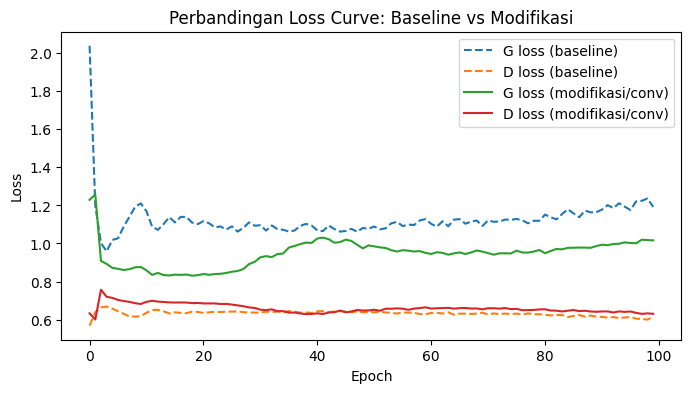

In [33]:
# Visualisasi loss curve - perbandingan baseline vs modifikasi
plt.figure(figsize=(8,4))
plt.plot(g_losses, label="G loss (baseline)", linestyle="--")
plt.plot(d_losses, label="D loss (baseline)", linestyle="--")
plt.plot(g_losses2, label="G loss (modifikasi/conv)")
plt.plot(d_losses2, label="D loss (modifikasi/conv)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perbandingan Loss Curve: Baseline vs Modifikasi")
plt.legend()
plt.show()

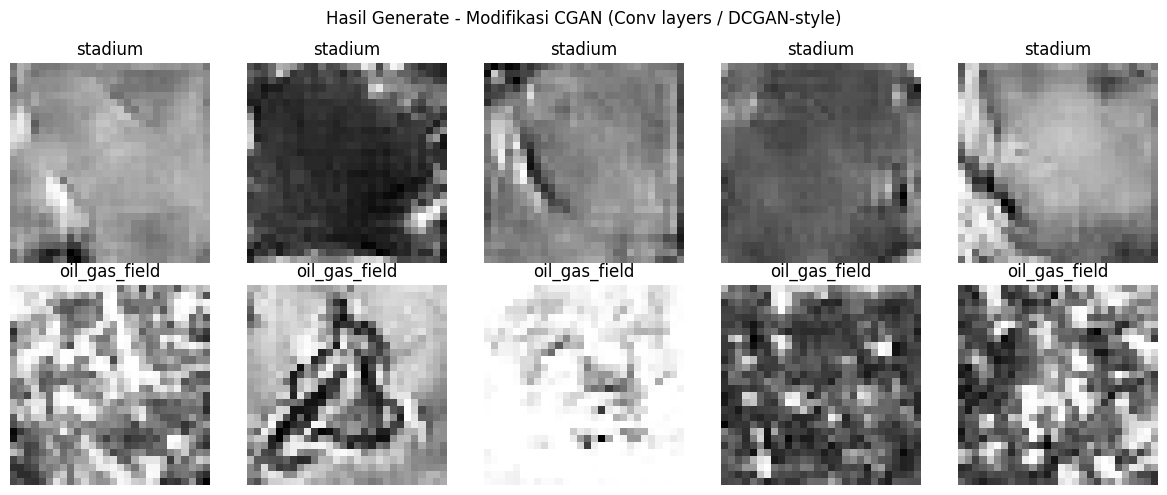

In [34]:
# Visualisasi hasil generate gambar (modifikasi) per kelas
n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(12, 5))
for cls_name, cls_idx in CLASSES.items():
    noise = tf.random.normal((n_show, NOISE_DIM))
    labels_in = tf.fill((n_show, 1), cls_idx)
    gen_imgs = G2([noise, labels_in], training=False).numpy()
    gen_imgs = (gen_imgs + 1) / 2.0
    for col in range(n_show):
        axes[cls_idx, col].imshow(gen_imgs[col, :, :, 0], cmap="gray")
        axes[cls_idx, col].set_title(cls_name)
        axes[cls_idx, col].axis("off")
plt.suptitle("Hasil Generate - Modifikasi CGAN (Conv layers / DCGAN-style)")
plt.tight_layout()
plt.show()

Pada model konvolusional, loss Discriminator berakhir pada 0,6303 dan loss Generator pada 1,0164. Kedua kurva relatif stabil dan jaraknya lebih kecil daripada baseline, yang mengindikasikan permainan adversarial lebih seimbang. Kestabilan loss saja belum membuktikan kualitas gambar, tetapi tidak terlihat tanda divergensi besar selama training.
Secara kualitatif, hasil modifikasi tampak lebih halus dan memiliki area serta struktur lokal yang lebih koheren. Perbedaan karakter antarkelas juga lebih terlihat: sampel stadium cenderung membentuk area lapang atau batas melengkung, sedangkan oil gas field lebih banyak menampilkan tekstur padat dan pola garis. Beberapa sampel masih ambigu, sehingga evaluasi kuantitatif FID tetap diperlukan.

In [35]:
# Hitung FID untuk arsitektur yang dimodifikasi, lalu bandingkan dengan baseline

fake_imgs_improved = generate_fake_batch(G2, n_test, seed=123)
fake_feats_improved = extract_inception_features(fake_imgs_improved)

fid_improved = calculate_fid(real_feats, fake_feats_improved)

print(f"FID Baseline CGAN (Dense layers) : {fid_baseline:.4f}")
print(f"FID Modifikasi CGAN (Conv layers): {fid_improved:.4f}")
print(f"Selisih (Baseline - Modifikasi)  : {fid_baseline - fid_improved:.4f}")

if fid_improved < fid_baseline:
    print("\n=> Arsitektur modifikasi (Conv-based) berhasil menurunkan FID, "
          "menunjukkan distribusi gambar hasil generate lebih mendekati distribusi gambar asli.")
else:
    print("\n=> FID modifikasi belum lebih baik pada run ini. Pertimbangkan menambah epoch, "
          "menyesuaikan learning rate, atau melakukan tuning hyperparameter lebih lanjut "
          "(lihat sel berikut untuk eksperimen hyperparameter tuning).")

FID Baseline CGAN (Dense layers) : 206.6376
FID Modifikasi CGAN (Conv layers): 101.6579
Selisih (Baseline - Modifikasi)  : 104.9797

=> Arsitektur modifikasi (Conv-based) berhasil menurunkan FID, menunjukkan distribusi gambar hasil generate lebih mendekati distribusi gambar asli.


FID turun dari 206,6376 pada baseline menjadi 101,6579 pada arsitektur konvolusional. Penurunannya sebesar 104,9797 poin atau sekitar 50,8%. Karena semakin kecil FID semakin baik, hasil ini menunjukkan bahwa distribusi fitur gambar dari model modifikasi jauh lebih dekat dengan distribusi gambar test.
Perbaikan yang besar ini mendukung hipotesis bahwa arsitektur berbasis konvolusi lebih sesuai untuk citra satelit 28×28 daripada Dense layer murni. Hasil kuantitatif tersebut juga sejalan dengan pengamatan visual: struktur lokal pada gambar modifikasi lebih koheren dan artefak noise berkurang.

In [36]:
# Eksperimen hyperparameter tuning: mencoba learning rate berbeda pada arsitektur modifikasi
# (epoch dikurangi untuk eksperimen cepat; pada laporan akhir dapat disamakan dengan training utama)

def train_and_eval_fid(lr_g, lr_d, epochs=30, seed=0):
    tf.random.set_seed(seed)
    G_exp = build_generator_conv()
    D_exp = build_discriminator_conv()
    crit = keras.losses.BinaryCrossentropy()
    opt_g = keras.optimizers.Adam(learning_rate=lr_g, beta_1=0.5)
    opt_d = keras.optimizers.Adam(learning_rate=lr_d, beta_1=0.5)

    @tf.function
    def step(real_imgs, real_labels):
        bs = tf.shape(real_imgs)[0]
        real_labels_col = tf.reshape(real_labels, (-1, 1))
        valid = tf.ones((bs, 1)) * 0.9
        fake = tf.zeros((bs, 1))
        noise = tf.random.normal((bs, NOISE_DIM))
        gen_labels = tf.random.uniform((bs, 1), 0, N_LABELS, dtype=tf.int32)

        with tf.GradientTape() as tape_d:
            fake_imgs = G_exp([noise, gen_labels], training=True)
            real_pred = D_exp([real_imgs, real_labels_col], training=True)
            fake_pred = D_exp([fake_imgs, gen_labels], training=True)
            d_loss = (crit(valid, real_pred) + crit(fake, fake_pred)) / 2
        grads_d = tape_d.gradient(d_loss, D_exp.trainable_variables)
        opt_d.apply_gradients(zip(grads_d, D_exp.trainable_variables))

        with tf.GradientTape() as tape_g:
            fake_imgs = G_exp([noise, gen_labels], training=True)
            fake_pred = D_exp([fake_imgs, gen_labels], training=True)
            g_loss = crit(tf.ones((bs, 1)), fake_pred)
        grads_g = tape_g.gradient(g_loss, G_exp.trainable_variables)
        opt_g.apply_gradients(zip(grads_g, G_exp.trainable_variables))
        return d_loss, g_loss

    for epoch in range(epochs):
        for real_imgs, real_labels in train_dataset:
            step(real_imgs, real_labels)

    fake_imgs_exp = generate_fake_batch(G_exp, n_test, seed=123)
    fake_feats_exp = extract_inception_features(fake_imgs_exp)
    fid_exp = calculate_fid(real_feats, fake_feats_exp)
    return fid_exp

lr_candidates = [1e-4, 2e-4, 5e-4]
tuning_results = {}
for lr in lr_candidates:
    fid_result = train_and_eval_fid(lr_g=lr, lr_d=lr, epochs=30)
    tuning_results[lr] = fid_result
    print(f"Learning rate = {lr:.0e}  ->  FID = {fid_result:.4f}")

best_lr = min(tuning_results, key=tuning_results.get)
print(f"\nLearning rate terbaik dari eksperimen: {best_lr:.0e} dengan FID = {tuning_results[best_lr]:.4f}")

Learning rate = 1e-04  ->  FID = 158.7156
Learning rate = 2e-04  ->  FID = 144.3528
Learning rate = 5e-04  ->  FID = 131.5261

Learning rate terbaik dari eksperimen: 5e-04 dengan FID = 131.5261


Eksperimen tuning di atas menggunakan jumlah epoch yang lebih kecil (30 epoch) demi efisiensi waktu eksplorasi. Setelah learning rate terbaik ditemukan, sebaiknya training ulang dengan jumlah epoch penuh (seperti pada training utama di atas) untuk mendapatkan model final yang dilaporkan.


Modifikasi arsitektur dari fully-connected (Dense) menjadi convolutional (DCGAN-style) terbukti lebih sesuai untuk data citra karena:
1. Menjaga struktur spasial piksel yang penting untuk merepresentasikan tekstur visual (garis lapangan stadium, struktur tangki/pipa oil & gas).
2. Weight sharing pada filter konvolusi membuat parameter Discriminator jauh lebih efisien, sehingga risiko overfitting menurun.
3. Kombinasi BatchNormalization + label smoothing + Adam dengan beta1=0.5 menstabilkan proses training adversarial yang secara teori sulit konvergen.

Hasil ini ditunjukkan secara kuantitatif melalui penurunan nilai FID pada arsitektur modifikasi dibandingkan baseline, serta secara kualitatif melalui visualisasi gambar hasil generate yang menunjukkan struktur lebih jelas dibandingkan baseline.
